In [23]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
import datetime

In [2]:
rides = pd.read_csv("2011-capitalbikeshare-tripdata.zip")
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1226767 entries, 0 to 1226766
Data columns (total 9 columns):
Duration                1226767 non-null int64
Start date              1226767 non-null object
End date                1226767 non-null object
Start station number    1226767 non-null int64
Start station           1226767 non-null object
End station number      1226767 non-null int64
End station             1226767 non-null object
Bike number             1226767 non-null object
Member type             1226767 non-null object
dtypes: int64(3), object(6)
memory usage: 84.2+ MB


In [3]:
rides.head()

,Duration,Start date,End date,Start station number,Start station,End station number,End station,Bike number,Member type
0,3548,2011-01-01 00:01:29,2011-01-01 01:00:37,31620,5th & F St NW,31620,5th & F St NW,W00247,Member
1,346,2011-01-01 00:02:46,2011-01-01 00:08:32,31105,14th & Harvard St NW,31101,14th & V St NW,W00675,Casual
2,562,2011-01-01 00:06:13,2011-01-01 00:15:36,31400,Georgia & New Hampshire Ave NW,31104,Adams Mill & Columbia Rd NW,W00357,Member
3,434,2011-01-01 00:09:21,2011-01-01 00:16:36,31111,10th & U St NW,31503,Florida Ave & R St NW,W00970,Member
4,233,2011-01-01 00:28:26,2011-01-01 00:32:19,31104,Adams Mill & Columbia Rd NW,31106,Calvert & Biltmore St NW,W00346,Casual


In [4]:
del rides["Start station"]
del rides["End station"]

In [5]:
rides['Member type'].value_counts()

Member     979814
Casual     246949
Unknown         4
Name: Member type, dtype: int64

In [15]:
# your code here
rides = rides[rides['Member type'] == "Member"]
print('{:,d} Member rides'.format(len(rides)))

979,814 Member rides


In [16]:
rides['start'] = pd.to_datetime(rides['Start date'])
rides['start'].iloc[0]

Timestamp('2011-01-01 00:01:29')

In [17]:
rides['start'].tail(10).dt.strftime("%Y-%m-%d")

1226757    2011-12-31
1226758    2011-12-31
1226759    2011-12-31
1226760    2011-12-31
1226761    2011-12-31
1226762    2011-12-31
1226763    2011-12-31
1226764    2011-12-31
1226765    2011-12-31
1226766    2011-12-31
Name: start, dtype: object

In [18]:
rides['date'] = rides['start'].dt.date#strftime("%Y-%m-%d")
rides['hour'] = rides['start'].dt.hour

In [31]:
pd.crosstab(index=rides["date"], columns=rides["hour"])

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2011-01-01,13,30,26,9,1,1,0,2,7,6,...,69,67,50,51,22,27,23,31,17,24
2011-01-02,13,15,8,4,1,0,2,1,8,18,...,53,54,65,57,41,28,17,20,9,7
2011-01-03,5,2,0,0,1,3,28,62,151,79,...,59,58,66,143,147,99,48,48,19,11
2011-01-04,5,2,1,0,2,4,36,91,175,98,...,53,47,67,200,179,104,52,46,34,9
2011-01-05,6,6,2,0,2,3,33,86,189,107,...,49,52,83,183,165,125,79,40,39,18
2011-01-06,11,4,2,0,1,4,36,93,208,111,...,56,53,73,162,153,108,64,47,50,19
2011-01-07,12,5,1,0,1,5,26,74,189,123,...,42,62,81,177,115,91,48,38,34,14
2011-01-08,24,15,13,7,1,5,2,8,15,19,...,82,63,65,62,52,26,27,35,33,22
2011-01-09,24,12,11,4,1,1,1,5,10,19,...,60,76,75,59,43,39,37,18,10,6


In [34]:
# your code here. Use groupby and size. You'll end up with a Series with a hierarchical index; remember that the "get out of jail card" is .to_frame(name="NAME_GOES_HERE").reset_index(). 
grouped_as_index = rides.groupby(['date', 'hour']).size()
rides_by_hour = grouped_as_index.to_frame(name="rides").reset_index()
rides_by_hour.head()

,date,hour,rides
0,2011-01-01,0,13
1,2011-01-01,1,30
2,2011-01-01,2,26
3,2011-01-01,3,9
4,2011-01-01,4,1


In [50]:
len(rides_by_hour)

8623

In [53]:
assert len(rides_by_hour) > 365 * 23
assert 'date' in rides_by_hour.columns
assert 'hour' in rides_by_hour.columns
assert 'rides' in rides_by_hour.columns

# Exercise 2: Compute rides by day.
The resulting table should have 365 rows.

In [49]:
# your code here
rides_by_day = rides.groupby('date').size().to_frame('rides').reset_index()

In [54]:
assert len(rides_by_day) == 365
assert 'date' in rides_by_day.columns
assert 'rides' in rides_by_day.columns

# Exercise 3: Mark holidays.

The following code gets us a table of federal holidays. Please run it without changing it.

In [70]:
# Run this code unchanged.
holidays = pd.DataFrame({
    'date': USFederalHolidayCalendar().holidays(datetime.date(2011,1,1), datetime.date(2015,12,31)).date,
    'is_holiday': True})
holidays.head()

,date,is_holiday
0,2011-01-17,True
1,2011-02-21,True
2,2011-05-30,True
3,2011-07-04,True
4,2011-09-05,True


## 3.1: `join`
Join the `rides_by_hour` table with the `holidays` table to get a new table that has a column for whether the hour occurred on a holiday.

In [75]:
# your code here
rides_by_hour_with_holidays = pd.merge(
    rides_by_hour,
    holidays,
    left_on='date',
    right_on='date',
    how='left')
print(len(rides_by_hour_with_holidays))
rides_by_hour_with_holidays.head()

8623


,date,hour,rides,is_holiday
0,2011-01-01,0,13,NaN
1,2011-01-01,1,30,NaN
2,2011-01-01,2,26,NaN
3,2011-01-01,3,9,NaN
4,2011-01-01,4,1,NaN


In [76]:
assert len(rides_by_hour_with_holidays) == len(rides_by_hour), "Oops, lengths inconsistent!"
assert 'is_holiday' in rides_by_hour_with_holidays.columns

## 3.2: `fill`
Depending on how you completed ex 3.1, there may be some missing values in `is_holiday`. Use `fillna` on the `is_holiday` column to fill them in appropriately.

In [79]:
rides_by_hour_with_holidays['is_holiday'] = rides_by_hour_with_holidays['is_holiday'].fillna(False)
rides_by_hour_with_holidays.head()

,date,hour,rides,is_holiday
0,2011-01-01,0,13,False
1,2011-01-01,1,30,False
2,2011-01-01,2,26,False
3,2011-01-01,3,9,False
4,2011-01-01,4,1,False


In [80]:
assert not any(rides_by_hour_with_holidays['is_holiday'].isna())

In [118]:
rides_by_hour_with_holidays['day_of_week'] = [date.weekday() for date in rides_by_hour_with_holidays['date']]
rides_by_hour_with_holidays.sample(n=10)

,date,hour,rides,is_holiday,day_of_week
2161,2011-04-05,12,32,False,1
6085,2011-09-16,23,105,False,4
4505,2011-07-12,7,299,False,1
5091,2011-08-05,17,459,False,4
5517,2011-08-23,12,175,False,1
6647,2011-10-10,10,152,True,0
4520,2011-07-12,22,147,False,1
3471,2011-05-30,3,8,True,0
7636,2011-11-20,16,218,False,6
8191,2011-12-13,20,153,False,1


In [122]:
rides_by_hour_with_holidays['is_weekend'] = (
    (rides_by_hour_with_holidays['day_of_week'] != 0) & 
    (rides_by_hour_with_holidays['day_of_week'] != 6))
rides_by_hour_with_holidays['is_workingday'] = (
    ~rides_by_hour_with_holidays['is_holiday'] & ~rides_by_hour_with_holidays['is_weekend'])

# Weather Data
Our main goal will be to get the hourly temperature data.

The original wranglers used a weather data source that does not seem to provide downloadable data anymore. But we can use the US government's records. They're in a cumbersome format, which will provide us an excuse to practice some **data cleaning**!

First challenge is where to find the data. Here's how we solved this hard problem:

There's a "Find a Station" tool, but it's confusing how to use the results. https://www.ncdc.noaa.gov/data-access/land-based-station-data/station-metadata has a link to a [station list file](ftp://ftp.ncdc.noaa.gov/pub/data/noaa/isd-history.txt). Searching that, it looks like the code for Reagan Airport is 724050 13743. So the file is
https://www.ncei.noaa.gov/data/global-hourly/access/2011/72405013743.csv

Poking around in that site revealed two documents that look very important:
- https://www.ncei.noaa.gov/data/global-hourly/doc/isd-format-document.pdf
- https://www.ncei.noaa.gov/data/global-hourly/doc/CSV_HELP.pdf



In [83]:
# Run this to load the file directly from the NOAA website.
# You may want to make a local copy and read it in from there instead.
weather = pd.read_csv("https://www.ncei.noaa.gov/data/global-hourly/access/2011/72405013743.csv")

In [88]:
print(len(weather))
weather.head()

14558


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OE1,OE2,OE3,RH1,RH2,RH3,REM,EQD,temp_raw,temp_quality_code
0,72405013743,2011-01-01T00:00:00,4,38.8472,-77.03454,3.0,"WASHINGTON REAGAN NATIONAL AIRPORT, VA US",FM-12,KDCA,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN092AAXX 01004 72405 32966 21704 10056 2101...,NaN,+0056,1
1,72405013743,2011-01-01T00:52:00,7,38.8472,-77.03454,3.0,"WASHINGTON REAGAN NATIONAL AIRPORT, VA US",FM-15,KDCA,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10012/31/10 19:52:03 METAR KDCA 010052Z 000...,NaN,+0056,5
2,72405013743,2011-01-01T01:52:00,7,38.8472,-77.03454,3.0,"WASHINGTON REAGAN NATIONAL AIRPORT, VA US",FM-15,KDCA,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10012/31/10 20:52:03 METAR KDCA 010152Z 000...,NaN,+0050,5
3,72405013743,2011-01-01T02:52:00,7,38.8472,-77.03454,3.0,"WASHINGTON REAGAN NATIONAL AIRPORT, VA US",FM-15,KDCA,V030,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10612/31/10 21:52:03 METAR KDCA 010252Z 180...,NaN,+0039,5
4,72405013743,2011-01-01T03:00:00,4,38.8472,-77.03454,3.0,"WASHINGTON REAGAN NATIONAL AIRPORT, VA US",FM-12,KDCA,V020,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN076AAXX 01034 72405 32966 41803 10039 2100...,NaN,+0039,1


In [101]:
weather['timestamp'] = pd.to_datetime(weather['DATE'])
weather['timestamp'].head()

0   2011-01-01 00:00:00
1   2011-01-01 00:52:00
2   2011-01-01 01:52:00
3   2011-01-01 02:52:00
4   2011-01-01 03:00:00
Name: timestamp, dtype: datetime64[ns]

Looking at the CSV help document, we see:

> AIR-TEMPERATURE-OBSERVATION air temperature is abbreviated as the column header TMP

So we'll look at the TMP column:

In [102]:
weather['TMP'].head()

0    +0056,1
1    +0056,5
2    +0050,5
3    +0039,5
4    +0039,1
Name: TMP, dtype: object

**Huh? What's that format?**  See pages 10 and 11 of "isd-format-document.pdf".

In [103]:
weather[['temp_raw', 'temp_quality_code']] = weather['TMP'].str.split(',', n=1, expand=True)
weather[['temp_raw', 'temp_quality_code']].head()

,temp_raw,temp_quality_code
0,+0056,1
1,+0056,5
2,+0050,5
3,+0039,5
4,+0039,1


In [104]:
weather['temp_quality_code'].value_counts(dropna=False)

5    11266
1     2906
A        7
Name: temp_quality_code, dtype: int64

Meanings:

* 5: Passed QC
* 1: Passed QC
* 9: Outside of limits
* A: suspect but good


In [105]:
weather[weather.temp_quality_code == "A"].temp_raw

2331    +0220
5071    +0180
6636    +0220
7251    +0330
8191    +0390
8914    +0280
9038    +0250
Name: temp_raw, dtype: object

In [106]:
weather['temp_is_valid'] = weather['temp_quality_code'].isin(["5", "1", "A"])
weather = weather[weather['temp_is_valid']].copy()

In [107]:
weather['temp_C'] = pd.to_numeric(weather['temp_raw']) / 10.

In [109]:
weather['date'] = weather['timestamp'].dt.date
weather['hour'] = weather['timestamp'].dt.hour

In [110]:
hourly_temp_data = weather.groupby(['date', 'hour'])['temp_C'].mean().reset_index()
hourly_temp_data.head()

,date,hour,temp_C
0,2011-01-01,0,5.60
1,2011-01-01,1,5.00
2,2011-01-01,2,3.90
3,2011-01-01,3,3.05
4,2011-01-01,4,3.30


In [137]:
merged_data = pd.merge(
    rides_by_hour_with_holidays,
    hourly_temp_data,
    on=['date', 'hour'])

# Move "rides" to the end.
merged_data['rides'] = merged_data.pop('rides')
pd.io.clipboard.copy(merged_data.iloc[::1000].to_html())

In [125]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8622 entries, 0 to 8621
Data columns (total 8 columns):
date             8622 non-null object
hour             8622 non-null int64
is_holiday       8622 non-null bool
day_of_week      8622 non-null int64
is_weekend       8622 non-null bool
is_workingday    8622 non-null bool
temp_C           8622 non-null float64
rides            8622 non-null int64
dtypes: bool(3), float64(1), int64(3), object(1)
memory usage: 429.4+ KB


In [128]:
import seaborn as sns
%matplotlib inline

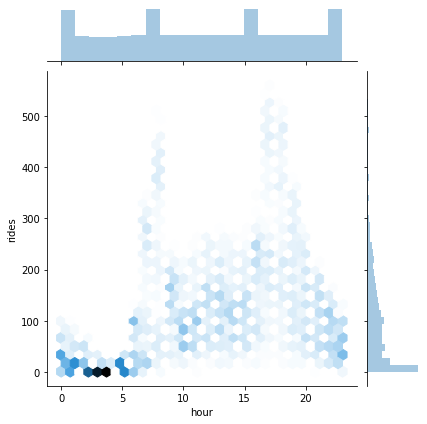

In [129]:
sns.jointplot(x='hour', y='rides', data=merged_data, kind='hex')

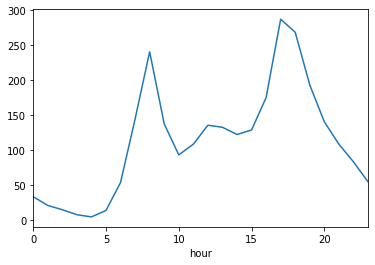

In [130]:
merged_data.groupby('hour').rides.mean().plot()